#### 1) import the library

In [1]:
%load_ext watermark
%watermark -v -p numpy,pandas,matplotlib

Python implementation: CPython
Python version       : 3.10.13
IPython version      : 8.25.0

numpy     : 1.26.4
pandas    : 2.2.2
matplotlib: 3.9.0



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

#### 2) Loading the Dataset

In [3]:
# Reading the data from an excel file
file = r'/Users/teslim/OneDrive/generaldata/1_uk_2024_election.xlsx'
df = pd.read_excel(file, sheet_name=3)
df

,X1,X2,label
0,60.3,37.0,0
1,58.6,42.8,0
2,57.4,41.2,1
3,56.5,40.5,1
4,53.4,38.4,1
...,...,...,...
644,56.5,39.2,0
645,63.5,39.3,0
646,54.2,43.7,0
647,70.3,39.4,1


In [4]:
# displaying columns headers, and checking for any space in the column names
df.columns = df.columns.str.strip()
df

,X1,X2,label
0,60.3,37.0,0
1,58.6,42.8,0
2,57.4,41.2,1
3,56.5,40.5,1
4,53.4,38.4,1
...,...,...,...
644,56.5,39.2,0
645,63.5,39.3,0
646,54.2,43.7,0
647,70.3,39.4,1


In [5]:
# checking for missing values
df.isnull().sum()

X1       1
X2       1
label    0
dtype: int64

In [6]:
# filling missing values with the mean of the column
df.fillna(df.mean(), inplace=True)

In [7]:
# checking for missing values after filling
df.isnull().sum()

X1       0
X2       0
label    0
dtype: int64

In [8]:
# Checking the first few rows of the data to confirm the data types 
df.dtypes

X1       float64
X2       float64
label      int64
dtype: object

In [9]:
# Changing the data types of the columns to integer

for col in df.columns:
    df[col] = df[col].astype('int')
    

df.dtypes


X1       int64
X2       int64
label    int64
dtype: object

In [10]:
# Extracting the features from the data, and assigning it to a variable X_train
X_train = df[["X1", "X2"]].values
print(X_train)
print('The shape of the Train data set', X_train.shape)

[[60 37]
 [58 42]
 [57 41]
 ...
 [54 43]
 [70 39]
 [54 56]]
The shape of the Train data set (649, 2)


In [11]:
# Extracting the target variable from the data, and assigning it to a variable y_train
y_train = df["label"].values
print(y_train)
print('The shape of the lable data set', y_train.shape)

[0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0
 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1
 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1
 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0
 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0
 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1
 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1
 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0
 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1 1
 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 0 1 1 1
 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0
 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1
 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1
 1 1 0 0 1 1 1 1 1 0 0 1 

In [12]:
# Checking the distribution of the target variable in the data set
np.bincount(y_train)

array([204, 445])

#### 3) Visualizing the dataset

<Axes: xlabel='X1', ylabel='X2'>

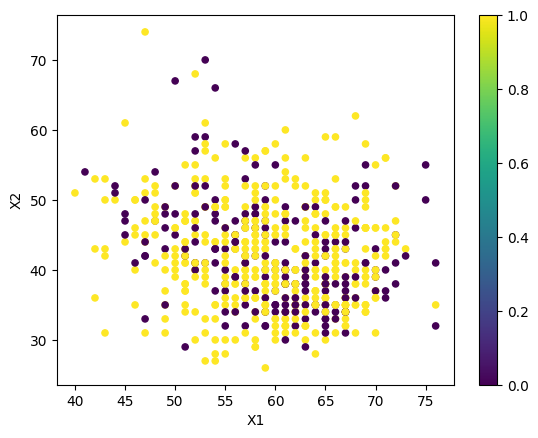

In [13]:
df['label_numeric'] = df['label'].astype('category').cat.codes
df[['X1', 'X2']].plot(x='X1', y='X2', kind='scatter', c=df['label_numeric'], colormap='viridis')


In [14]:
class Perceptron:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = [0.0 for _ in range(num_features)]
        self.bias = 0.0

In [15]:
# Create a perceptron object
ppn = Perceptron(num_features=2)

In [16]:
# checking the weights of the perceptron
ppn.weights

[0.0, 0.0]

In [17]:
class Perceptron:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = [0.0 for _ in range(num_features)]
        self.bias = 0.0

    def forward(self, x):
        weighted_sum_z = self.bias
        for i, _ in enumerate(self.weights):
            weighted_sum_z += x[i] * self.weights[i]

        if weighted_sum_z > 0.0:
            prediction = 1
        else:
            prediction = 0

        return prediction

In [18]:
ppn = Perceptron(num_features=2)

x = [1.1, 2.1]
ppn.forward(x)

0

In [22]:
1
2
import torch
torch.__version__

'2.4.0'

In [24]:
import torch
torch.cuda.is_available()


False

In [ ]:
import torch
torch.cuda.is_available()


False

In [25]:
print(torch.backends.mps.is_available())

True


In [26]:
%load_ext watermark
%watermark -a 'Sebastian Raschka' -v -p torch

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Sebastian Raschka

Python implementation: CPython
Python version       : 3.10.13
IPython version      : 8.25.0

torch: 2.4.0



In [48]:
import torch

tensor0d = torch.tensor(1)

tensor1d = torch.tensor([1, 2, 3])

tensor2d = torch.tensor([[1, 2], 
                         [3, 4]])

tensor3d = torch.tensor([[[1, 2], [3, 4]], 
                         [[5, 6], [7, 8]]])

print(tensor0d)

tensor(1)


In [30]:
print(tensor1d)

tensor([1, 2, 3])


In [31]:
print(tensor2d)

tensor([[1, 2],
        [3, 4]])


In [32]:
a = torch.tensor([1, 2, 3])
print(a.dtype)

torch.int64


In [38]:
data = torch.tensor([[1, 2, 3], [4,5,6]]) 
data

tensor([[1, 2, 3],
        [4, 5, 6]])

In [39]:
data.shape

torch.Size([2, 3])

In [43]:
data.reshape(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [44]:
data.view(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [2]:
import torch

# Create a tensor with requires_grad=True to track operations
x = torch.tensor(2.0, requires_grad=True)

# Perform some operations
y = x ** 2  # Square the tensor (y = x^2)
z = 3 * y + 1  # A more complex operation (z = 3x^2 + 1)

# Compute the gradient (backpropagation)
z.backward()

# Access the gradient (dz/dx)
print(x.grad)  # This will print the gradient of z with respect to x


tensor(12.)


In [7]:

# Create a simple model parameter with requires_grad=True
weight = torch.randn((), requires_grad=True)

# Perform a forward pass
prediction = weight * 2  # A simple prediction

# Define a loss function (how far off is the prediction from the actual value?)
loss = (prediction - 10) ** 2

# Compute gradients using autograd
loss.backward()

# Access the gradient of weight
print(weight.grad)


tensor(-49.7701)


In [8]:
import torch.nn.functional as F

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])
z = x1 * w1 + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

In [13]:
print(loss)
print(a)
print(z)

tensor(0.0852)
tensor([0.9183])
tensor([2.4200])


In [14]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b 
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

In [15]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


In [20]:

import torch

# Create a tensor with requires_grad=True
x = torch.tensor(2.0, requires_grad=True)

# Perform some operations
y = x ** 2 + 3 * x + 1  # A function of x

# Compute the gradient of y with respect to x
y.backward()

# Access the gradient
print(x.grad)  # This prints the gradient of y with respect to x



tensor(7.)


In [27]:
class NeuralNetwork(torch.nn.Module):
    """
    A simple feedforward neural network with one input layer, two hidden layers, and one output layer.

    Attributes:
        layers (torch.nn.Sequential): A sequential container of the neural network layers.

    Methods:
        forward(x):
            Defines the forward pass of the neural network.
            Args:
                x (torch.Tensor): Input tensor.
            Returns:
                torch.Tensor: Output tensor after passing through the network.
    """

        """
        Initializes the neural network with the specified number of input and output neurons.

        Args:
            num_inputs (int): Number of input features.
            num_outputs (int): Number of output features.
        """

        """
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after passing through the network.
        """
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits


In [28]:
model = NeuralNetwork(50, 3)

In [29]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [30]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213
